# Exploratory Data Analysis (EDA) for Crowd Prediction

This notebook performs:
- Raw vs Clean data quality checks (missing values, duplicates, invalid values, inconsistencies)
- Temporal analysis (hourly, daily, weekly)
- Location analysis
- Weather impact analysis
- Holiday and weekend effects
- Cross-feature analysis
- Anomaly detection
- Seasonality analysis
- Correlation and feature importance visualizations

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

In [11]:
# Update these paths
raw_path = Path("event_level_data_dirty.csv")
clean_path = Path("event_level_data_clean.csv")

raw_df = pd.read_csv(raw_path)
clean_df = pd.read_csv(clean_path)

print("Raw shape :", raw_df.shape)
print("Clean shape:", clean_df.shape)

Raw shape : (216043, 14)
Clean shape: (211807, 13)


In [13]:
def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def to_numeric_safe(series):
    return pd.to_numeric(series, errors="coerce")

def normalize_text_series(series):
    s = series.astype(str).str.strip().str.lower()
    s = s.replace({"nan": np.nan, "none": np.nan, "null": np.nan, "": np.nan})
    return s

def safe_bar(df_plot, x, y, title, xlabel=None, ylabel=None, rotate=0):
    if df_plot is None or df_plot.empty:
        print(f"Skipping chart: {title} (no data)")
        return
    plt.figure(figsize=(11, 5))
    sns.barplot(data=df_plot, x=x, y=y)
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x)
    plt.ylabel(ylabel if ylabel else y)
    if rotate:
        plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.show()

def safe_line(df_plot, x, y, title, xlabel=None, ylabel=None):
    if df_plot is None or df_plot.empty:
        print(f"Skipping chart: {title} (no data)")
        return
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df_plot, x=x, y=y, marker="o")
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x)
    plt.ylabel(ylabel if ylabel else y)
    plt.tight_layout()
    plt.show()

def infer_target_column(df):
    candidates = ["crowd_count", "crowdedness", "crowd_level", "crowd_density", "target", "y"]
    for c in candidates:
        if c in df.columns:
            return c
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for c in numeric_cols:
        if "crowd" in c.lower() or "count" in c.lower():
            return c
    return None

def ensure_datetime_columns(df):
    df = df.copy()

    ts_col = first_existing(df, ["timestamp", "event_timestamp", "datetime", "date_time"])
    if ts_col is not None:
        df["_dt"] = pd.to_datetime(df[ts_col], errors="coerce")
    else:
        df["_dt"] = pd.NaT

    if "event_date" in df.columns:
        df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce").dt.date
    elif df["_dt"].notna().any():
        df["event_date"] = df["_dt"].dt.date

    if "hour_of_day" in df.columns:
        df["hour_of_day"] = pd.to_numeric(df["hour_of_day"], errors="coerce")
    elif df["_dt"].notna().any():
        df["hour_of_day"] = df["_dt"].dt.hour

    if "day_of_week" not in df.columns and df["_dt"].notna().any():
        df["day_of_week"] = df["_dt"].dt.dayofweek

    if "month" not in df.columns and df["_dt"].notna().any():
        df["month"] = df["_dt"].dt.month

    if "is_weekend" not in df.columns:
        if "_dt" in df.columns and df["_dt"].notna().any():
            df["is_weekend"] = (df["_dt"].dt.dayofweek >= 5).astype(int)
        elif "day_of_week" in df.columns:
            temp = pd.to_numeric(df["day_of_week"], errors="coerce")
            if temp.notna().any():
                df["is_weekend"] = (temp >= 5).astype("Int64")

    return df

In [15]:
raw_df = ensure_datetime_columns(raw_df)
clean_df = ensure_datetime_columns(clean_df)

target_col = infer_target_column(clean_df)

location_col = first_existing(clean_df, ["location_name", "location", "area", "station", "zone"])
weather_col = first_existing(clean_df, ["weather", "weather_condition", "weather_main"])
temp_col = first_existing(clean_df, ["temperature", "temp"])
humidity_col = first_existing(clean_df, ["humidity", "humid"])
holiday_col = first_existing(clean_df, ["is_public_holiday", "public_holiday", "is_holiday"])
lat_col = first_existing(clean_df, ["latitude", "lat"])
lon_col = first_existing(clean_df, ["longitude", "lon", "lng"])

print("Inferred target column:", target_col)
print("location_col:", location_col)
print("weather_col :", weather_col)
print("temp_col    :", temp_col)
print("humidity_col:", humidity_col)
print("holiday_col :", holiday_col)
print("lat/lon     :", lat_col, lon_col)

Inferred target column: None
location_col: location_name
weather_col : weather
temp_col    : temperature
humidity_col: humidity
holiday_col : is_public_holiday
lat/lon     : lat None


In [17]:
display(raw_df.head())
display(clean_df.head())

,record_id,timestamp,day_of_week,hour_of_day,is_weekend,is_public_holiday,lat,long,weather,temperature,humidity,location_id,location_name,timezone_info,_dt,event_date,month
0,1,2025-01-01 07:01:00,2.0,7.0,False,True,1.280884,{}103.869885{},rainy,24.8,93.5,0,SEMBAWANG EATING HOUSE,NaN,2025-01-01 07:01:00,2025-01-01,1.0
1,2,2025-01-01 07:16:00,2.0,7.0,\r\nFalse\r\n,\nTrue\n,1.280884,103.869885,rainy,60.0,91.6,0,SEMBAWANG EATING HOUSE,NaN,2025-01-01 07:16:00,2025-01-01,1.0
2,3,NaN,2.0,7.0,False,NaN,1.280884,103.869885,cloudy,()23.7,86.9,0,SEMBAWANG EATING HOUSE,NaN,NaT,NaT,NaN
3,4,2025-01-01 07:38:00,2.0,7.0,@False,True,1.280884,103.869885,cloudy,24.2,85.7,0,SEMBAWANG EATING HOUSE,NaN,2025-01-01 07:38:00,2025-01-01,1.0
4,5,2025-01-01 07:39:00,NaN,7.0,\r\nFalse\r\n,True,\r\n1.280884\r\n,103.869885,rainy,24.7,91().2,0,SEMBAWANG EATING HOUSE,NaN,2025-01-01 07:39:00,2025-01-01,1.0


,record_id,timestamp,day_of_week,hour_of_day,is_weekend,is_public_holiday,lat,long,weather,temperature,humidity,location_id,location_name,_dt,event_date,month
0,1,2025-01-01 07:01:00,2,7,False,True,1.280884,103.869885,rainy,24.8,93.5,0,SEMBAWANG EATING HOUSE,2025-01-01 07:01:00,2025-01-01,1
1,2,2025-01-01 07:16:00,2,7,False,True,1.280884,103.869885,rainy,24.9,91.6,0,SEMBAWANG EATING HOUSE,2025-01-01 07:16:00,2025-01-01,1
2,3,2025-01-01 07:30:00,2,7,False,True,1.280884,103.869885,cloudy,23.7,86.9,0,SEMBAWANG EATING HOUSE,2025-01-01 07:30:00,2025-01-01,1
3,4,2025-01-01 07:38:00,2,7,False,True,1.280884,103.869885,cloudy,24.2,85.7,0,SEMBAWANG EATING HOUSE,2025-01-01 07:38:00,2025-01-01,1
4,5,2025-01-01 07:39:00,2,7,False,True,1.280884,103.869885,rainy,24.7,91.2,0,SEMBAWANG EATING HOUSE,2025-01-01 07:39:00,2025-01-01,1


In [19]:
print("RAW COLUMNS")
display(pd.DataFrame({"column": raw_df.columns, "dtype": [str(t) for t in raw_df.dtypes]}))

print("CLEAN COLUMNS")
display(pd.DataFrame({"column": clean_df.columns, "dtype": [str(t) for t in clean_df.dtypes]}))

RAW COLUMNS


,column,dtype
0,record_id,int64
1,timestamp,object
2,day_of_week,float64
3,hour_of_day,float64
4,is_weekend,object
5,is_public_holiday,object
6,lat,object
7,long,object
8,weather,object
9,temperature,object


CLEAN COLUMNS


,column,dtype
0,record_id,int64
1,timestamp,object
2,day_of_week,int64
3,hour_of_day,int64
4,is_weekend,bool
5,is_public_holiday,bool
6,lat,float64
7,long,float64
8,weather,object
9,temperature,float64


In [21]:
raw_missing_pct = (raw_df.isna().mean() * 100).sort_values(ascending=False)
clean_missing_pct = (clean_df.isna().mean() * 100).sort_values(ascending=False)

missing_compare = pd.DataFrame({
    "raw_missing_pct": raw_missing_pct,
    "clean_missing_pct": clean_missing_pct
}).fillna(0).sort_values("raw_missing_pct", ascending=False)

display(missing_compare.head(20).round(2))

,raw_missing_pct,clean_missing_pct
timezone_info,98.10,0.0
is_weekend,4.92,0.0
weather,4.89,0.0
timestamp,4.89,0.0
month,4.89,0.0
_dt,4.89,0.0
event_date,4.89,0.0
is_public_holiday,4.88,0.0
location_name,4.82,0.0
day_of_week,4.81,0.0


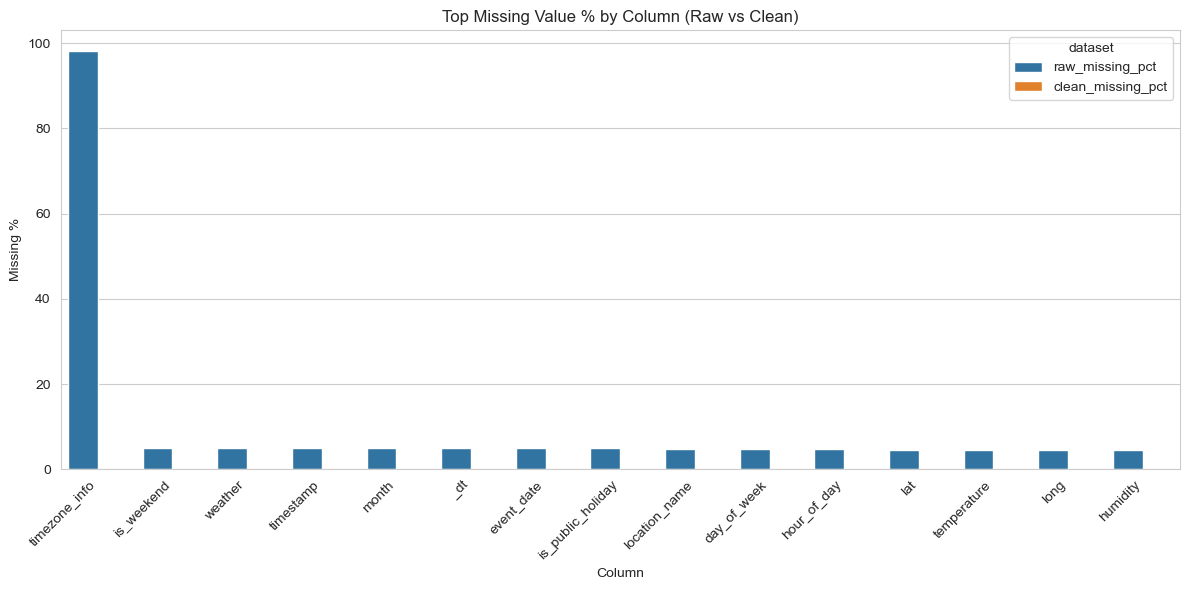

In [23]:
top_missing = missing_compare.head(15).reset_index().rename(columns={"index": "column"})
top_missing_melt = top_missing.melt(id_vars="column", var_name="dataset", value_name="missing_pct")

plt.figure(figsize=(12, 6))
sns.barplot(data=top_missing_melt, x="column", y="missing_pct", hue="dataset")
plt.title("Top Missing Value % by Column (Raw vs Clean)")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,dataset,duplicate_count
0,Raw,4236
1,Clean,0


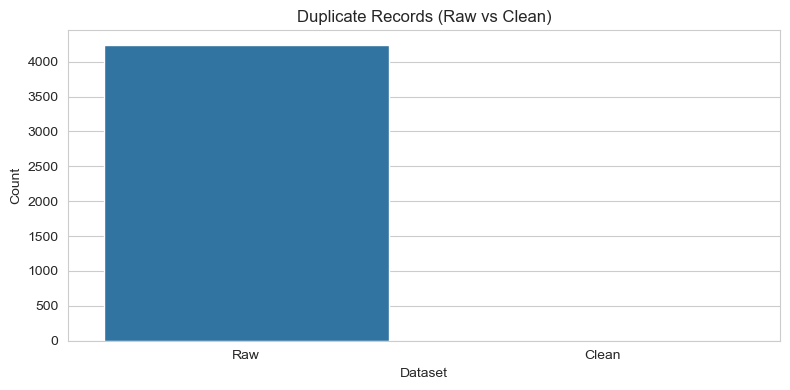

In [24]:
id_col = first_existing(raw_df, ["record_id", "id", "event_id"])
if id_col and id_col in clean_df.columns:
    dup_raw = raw_df[id_col].duplicated().sum()
    dup_clean = clean_df[id_col].duplicated().sum()
else:
    dup_raw = raw_df.duplicated().sum()
    dup_clean = clean_df.duplicated().sum()

dup_df = pd.DataFrame({
    "dataset": ["Raw", "Clean"],
    "duplicate_count": [dup_raw, dup_clean]
})

display(dup_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=dup_df, x="dataset", y="duplicate_count")
plt.title("Duplicate Records (Raw vs Clean)")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [25]:
def invalid_value_counts(df, temp_col=None, humidity_col=None):
    out = {}

    if "hour_of_day" in df.columns:
        h = pd.to_numeric(df["hour_of_day"], errors="coerce")
        out["invalid_hour_of_day"] = int(((h < 0) | (h > 23)).sum())

    if "day_of_week" in df.columns:
        d = pd.to_numeric(df["day_of_week"], errors="coerce")
        if d.notna().any():
            out["invalid_day_of_week"] = int(((d < 0) | (d > 6)).sum())

    if "month" in df.columns:
        m = pd.to_numeric(df["month"], errors="coerce")
        out["invalid_month"] = int(((m < 1) | (m > 12)).sum())

    if temp_col and temp_col in df.columns:
        t = pd.to_numeric(df[temp_col], errors="coerce")
        out["unlikely_temperature"] = int(((t < -20) | (t > 60)).sum())

    if humidity_col and humidity_col in df.columns:
        h2 = pd.to_numeric(df[humidity_col], errors="coerce")
        out["invalid_humidity"] = int(((h2 < 0) | (h2 > 100)).sum())

    return out

,Raw,Clean
invalid_hour_of_day,1785,0
invalid_day_of_week,0,0
invalid_month,0,0
unlikely_temperature,4111,0
invalid_humidity,4350,0


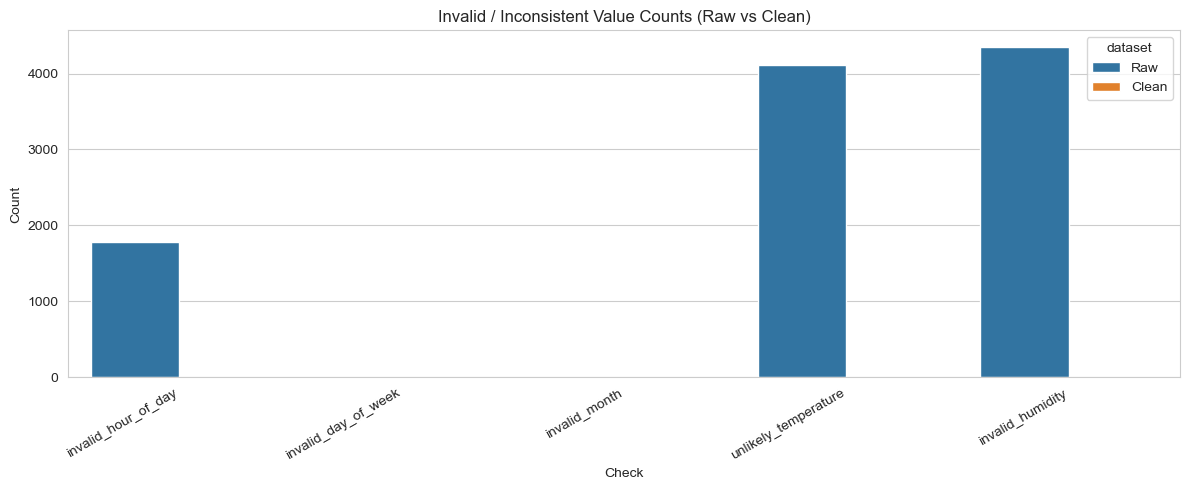

In [26]:
invalid_raw = invalid_value_counts(raw_df, temp_col=temp_col, humidity_col=humidity_col)
invalid_clean = invalid_value_counts(clean_df, temp_col=temp_col, humidity_col=humidity_col)

invalid_compare = pd.DataFrame({
    "Raw": pd.Series(invalid_raw),
    "Clean": pd.Series(invalid_clean)
}).fillna(0).astype(int)

display(invalid_compare)

if not invalid_compare.empty:
    invalid_plot = invalid_compare.reset_index().rename(columns={"index": "check"})
    invalid_plot = invalid_plot.melt(id_vars="check", var_name="dataset", value_name="count")

    plt.figure(figsize=(12, 5))
    sns.barplot(data=invalid_plot, x="check", y="count", hue="dataset")
    plt.title("Invalid / Inconsistent Value Counts (Raw vs Clean)")
    plt.xlabel("Check")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

,dataset,unique_weather_labels
0,Raw,1703
1,Clean,4


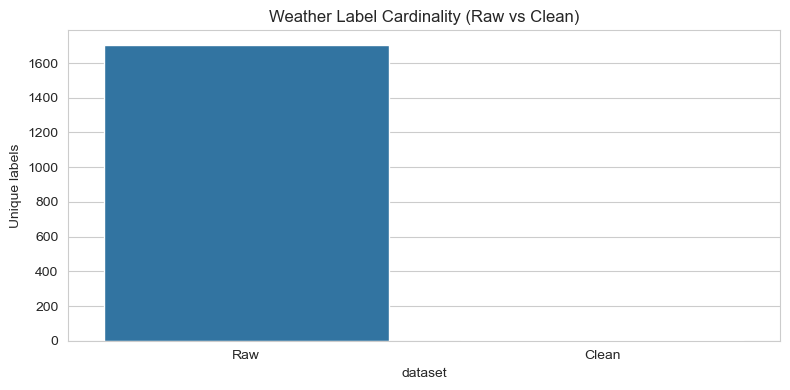

,normalized,num_raw_variants
0,clear,28
1,rainy,28
2,cloudy,28
3,night_clear,21
4,clo#udy,15
5,ra||iny,14
6,clo\udy,13
7,clo||udy,13
8,clo@udy,13
9,clo//udy,13


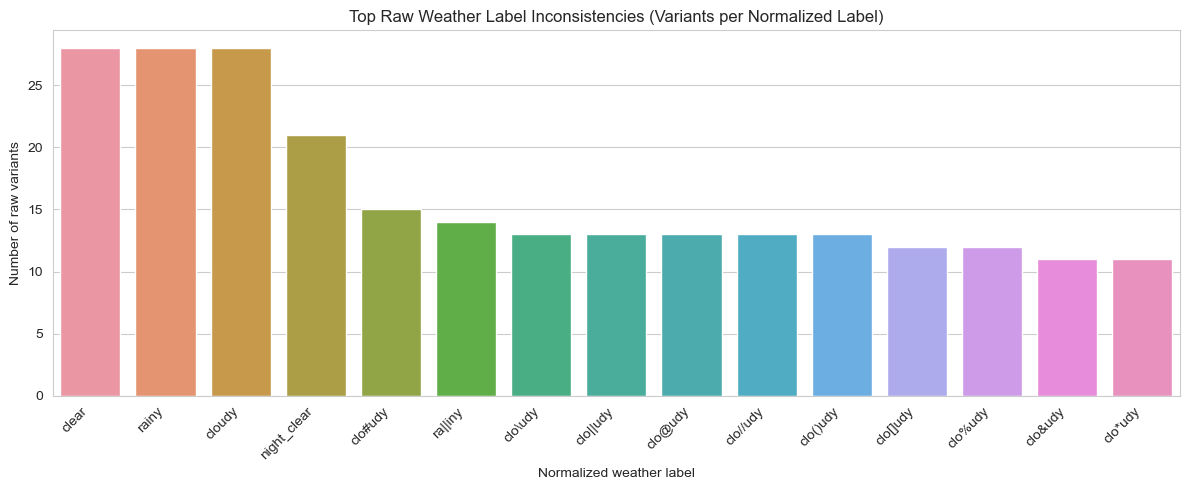

In [30]:
if weather_col and weather_col in raw_df.columns and weather_col in clean_df.columns:
    raw_weather_unique = raw_df[weather_col].astype(str).nunique(dropna=True)
    clean_weather_unique = clean_df[weather_col].astype(str).nunique(dropna=True)

    w_comp = pd.DataFrame({
        "dataset": ["Raw", "Clean"],
        "unique_weather_labels": [raw_weather_unique, clean_weather_unique]
    })
    display(w_comp)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=w_comp, x="dataset", y="unique_weather_labels")
    plt.title("Weather Label Cardinality (Raw vs Clean)")
    plt.ylabel("Unique labels")
    plt.tight_layout()
    plt.show()

    raw_weather_norm = normalize_text_series(raw_df[weather_col])
    raw_weather_variants = (
        pd.DataFrame({
            "raw_value": raw_df[weather_col].astype(str),
            "normalized": raw_weather_norm
        })
        .dropna(subset=["normalized"])
        .groupby("normalized")["raw_value"]
        .nunique()
        .sort_values(ascending=False)
        .reset_index(name="num_raw_variants")
    )

    top_weather_variants = raw_weather_variants.head(15)
    display(top_weather_variants)

    if not top_weather_variants.empty:
        plt.figure(figsize=(12, 5))
        sns.barplot(data=top_weather_variants, x="normalized", y="num_raw_variants")
        plt.title("Top Raw Weather Label Inconsistencies (Variants per Normalized Label)")
        plt.xlabel("Normalized weather label")
        plt.ylabel("Number of raw variants")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("Weather column not found in both raw and clean datasets.")

,dataset,unique_location_labels
0,Raw,3905
1,Clean,20


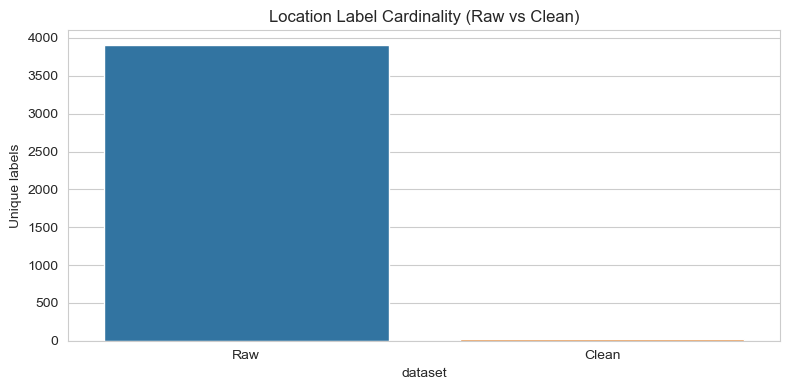

,normalized,num_raw_variants
0,chit chat & makan eating house,24
1,yummy curry eating house,21
2,hong xiang eating house,21
3,kheng jan eating house,21
4,henly huat drinks food court,21
5,food loft,21
6,s11 upper cross street food house,21
7,new garden coffee shop,21
8,6033 foodcourt llp,21
9,kenn's foodhouse,21


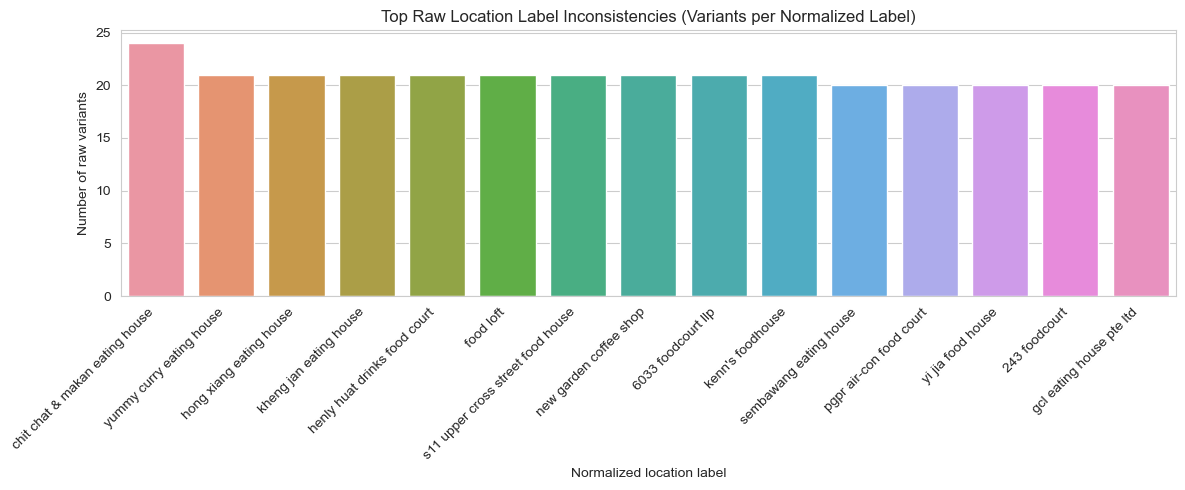

In [32]:
raw_location_col = first_existing(raw_df, ["location_name", "location", "area", "station", "zone"])
clean_location_col = first_existing(clean_df, ["location_name", "location", "area", "station", "zone"])

if raw_location_col and clean_location_col:
    raw_loc_unique = raw_df[raw_location_col].astype(str).nunique(dropna=True)
    clean_loc_unique = clean_df[clean_location_col].astype(str).nunique(dropna=True)

    loc_comp = pd.DataFrame({
        "dataset": ["Raw", "Clean"],
        "unique_location_labels": [raw_loc_unique, clean_loc_unique]
    })
    display(loc_comp)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=loc_comp, x="dataset", y="unique_location_labels")
    plt.title("Location Label Cardinality (Raw vs Clean)")
    plt.ylabel("Unique labels")
    plt.tight_layout()
    plt.show()

    raw_loc_norm = normalize_text_series(raw_df[raw_location_col])
    raw_loc_variants = (
        pd.DataFrame({
            "raw_value": raw_df[raw_location_col].astype(str),
            "normalized": raw_loc_norm
        })
        .dropna(subset=["normalized"])
        .groupby("normalized")["raw_value"]
        .nunique()
        .sort_values(ascending=False)
        .reset_index(name="num_raw_variants")
    )
    top_loc_variants = raw_loc_variants.head(15)
    display(top_loc_variants)

    if not top_loc_variants.empty:
        plt.figure(figsize=(12, 5))
        sns.barplot(data=top_loc_variants, x="normalized", y="num_raw_variants")
        plt.title("Top Raw Location Label Inconsistencies (Variants per Normalized Label)")
        plt.xlabel("Normalized location label")
        plt.ylabel("Number of raw variants")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("Location column not found in both raw and clean datasets.")

In [33]:
dq_summary = pd.DataFrame([{
    "raw_rows": len(raw_df),
    "clean_rows": len(clean_df),
    "duplicate_count_raw": int(dup_raw),
    "duplicate_count_clean": int(dup_clean),
    "missing_cells_raw": int(raw_df.isna().sum().sum()),
    "missing_cells_clean": int(clean_df.isna().sum().sum()),
    "target_col_detected": target_col if target_col else "Not detected"
}])

display(dq_summary)

,raw_rows,clean_rows,duplicate_count_raw,duplicate_count_clean,missing_cells_raw,missing_cells_clean,target_col_detected
0,216043,211807,4236,0,356196,0,Not detected


,hour_of_day,record_count
0,6,674
1,7,10388
2,8,10273
3,9,10313
4,10,6920
5,11,17066
6,12,17429
7,13,17465
8,14,17291
9,15,6981


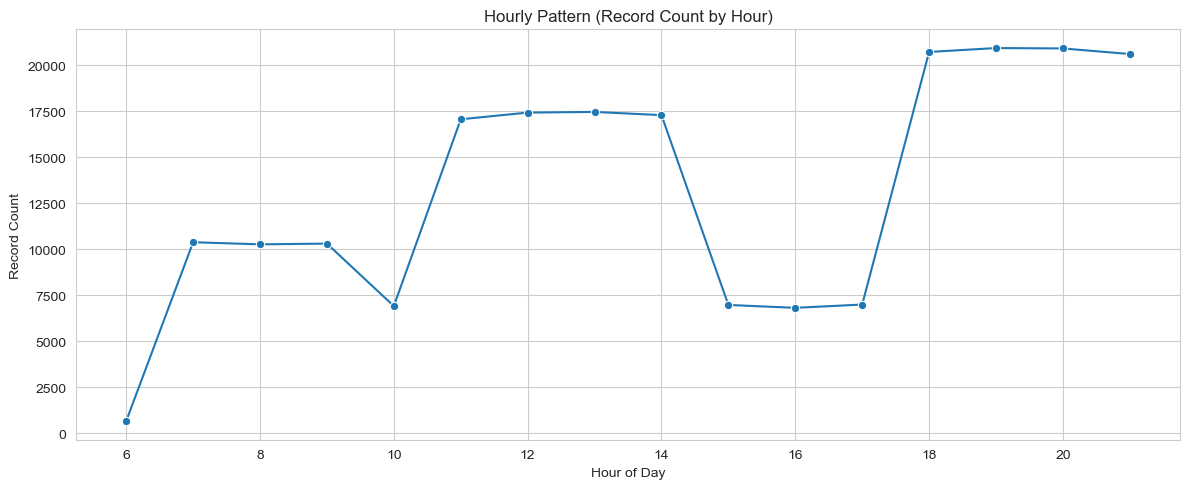

In [35]:
if "hour_of_day" in clean_df.columns:
    hourly_counts = (
        pd.to_numeric(clean_df["hour_of_day"], errors="coerce")
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
        .reset_index()
    )
    hourly_counts.columns = ["hour_of_day", "record_count"]
    display(hourly_counts)

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=hourly_counts, x="hour_of_day", y="record_count", marker="o")
    plt.title("Hourly Pattern (Record Count by Hour)")
    plt.xlabel("Hour of Day")
    plt.ylabel("Record Count")
    plt.tight_layout()
    plt.show()
else:
    print("hour_of_day column not found.")

,day_of_week,record_count,day_label
0,0,27501,Mon
1,1,26411,Tue
2,2,28423,Wed
3,3,28391,Thu
4,4,28019,Fri
5,5,37210,Sat
6,6,35852,Sun


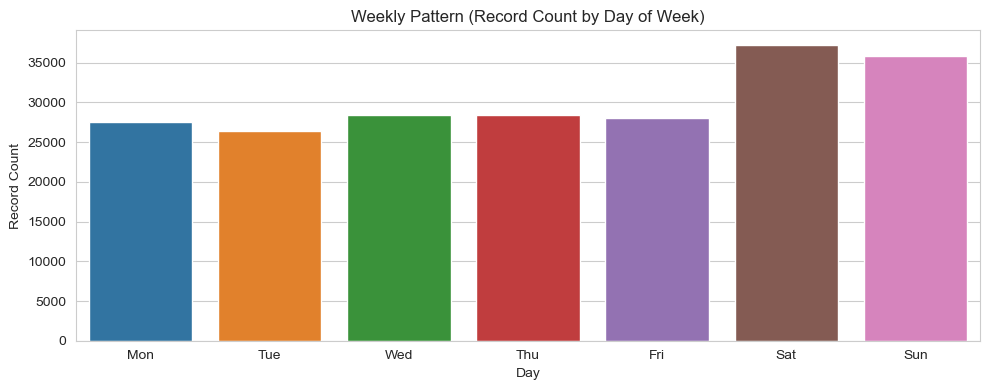

In [36]:
if "day_of_week" in clean_df.columns:
    day_temp = clean_df["day_of_week"].copy()
    day_num = pd.to_numeric(day_temp, errors="coerce")
    if day_num.notna().any():
        dow = day_num.dropna().astype(int).value_counts().sort_index().reset_index()
        dow.columns = ["day_of_week", "record_count"]
        day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
        dow["day_label"] = dow["day_of_week"].map(day_map)
        display(dow)

        plt.figure(figsize=(10, 4))
        sns.barplot(data=dow, x="day_label", y="record_count")
        plt.title("Weekly Pattern (Record Count by Day of Week)")
        plt.xlabel("Day")
        plt.ylabel("Record Count")
        plt.tight_layout()
        plt.show()
    else:
        dow = day_temp.astype(str).value_counts().reset_index()
        dow.columns = ["day_of_week", "record_count"]
        display(dow)

        plt.figure(figsize=(10, 4))
        sns.barplot(data=dow, x="day_of_week", y="record_count")
        plt.title("Weekly Pattern (Record Count by Day of Week)")
        plt.xlabel("Day")
        plt.ylabel("Record Count")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
else:
    print("day_of_week column not found.")

,month,record_count
0,1,36700
1,2,32093
2,3,36636
3,4,34919
4,5,37347
5,6,34112


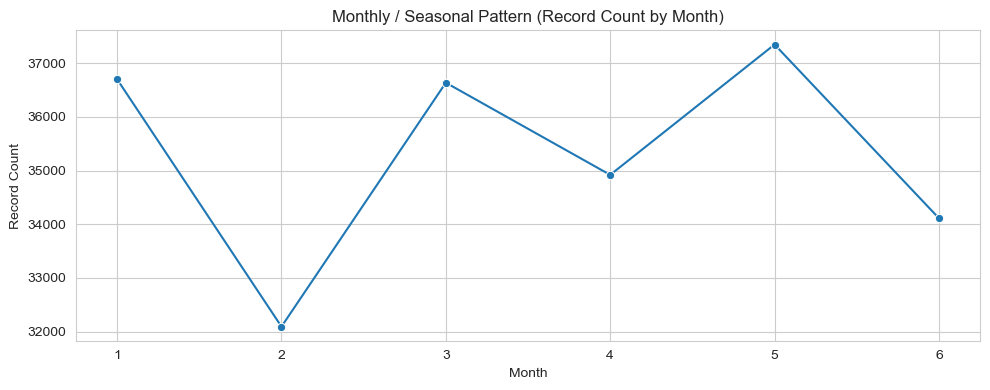

In [38]:
if "month" in clean_df.columns:
    month_counts = (
        pd.to_numeric(clean_df["month"], errors="coerce")
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
        .reset_index()
    )
    month_counts.columns = ["month", "record_count"]
    display(month_counts)

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=month_counts, x="month", y="record_count", marker="o")
    plt.title("Monthly / Seasonal Pattern (Record Count by Month)")
    plt.xlabel("Month")
    plt.ylabel("Record Count")
    plt.tight_layout()
    plt.show()
else:
    print("month column not found.")

,location,record_count
0,HLY EATING HOUSE,10783
1,SEMBAWANG EATING HOUSE,10736
2,6033 FOODCOURT LLP,10735
3,Chit Chat & Makan Eating House,10665
4,THE FOOD COURT,10627
5,TASTEBUD FOODCOURT,10622
6,FOOD LOFT,10615
7,HENLY HUAT DRINKS FOOD COURT,10612
8,BGAIN 442 EATING HOUSE,10598
9,GCL EATING HOUSE PTE LTD,10593


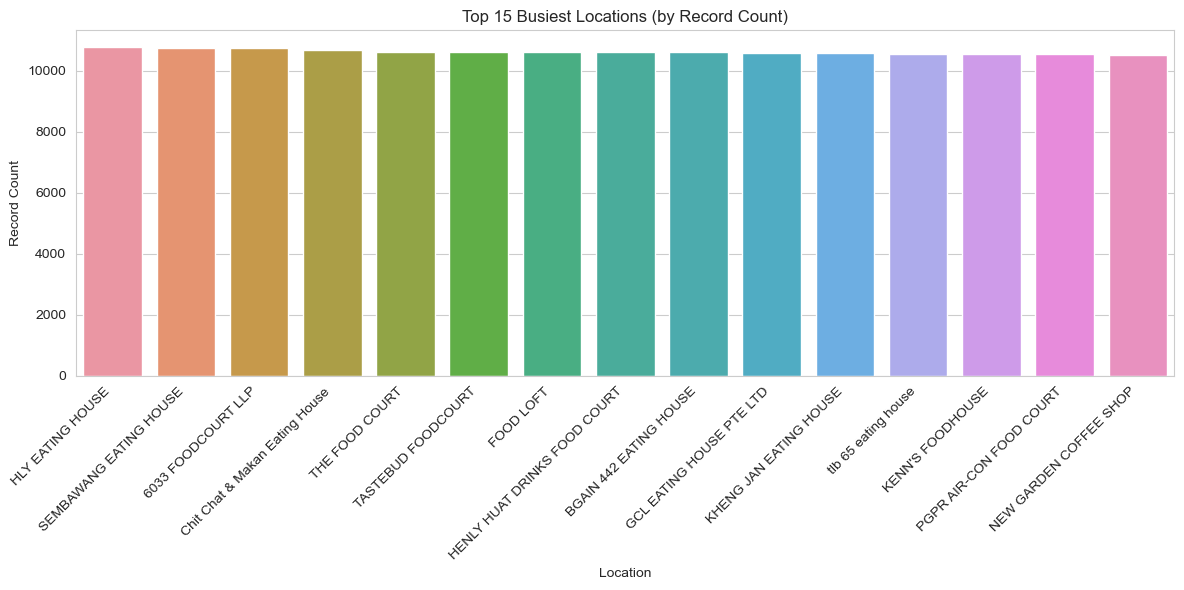

In [40]:
if location_col:
    top_locations = clean_df[location_col].astype(str).value_counts().head(15).reset_index()
    top_locations.columns = ["location", "record_count"]
    display(top_locations)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_locations, x="location", y="record_count")
    plt.title("Top 15 Busiest Locations (by Record Count)")
    plt.xlabel("Location")
    plt.ylabel("Record Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No location column detected.")

In [43]:
if lat_col and lon_col:
    geo_df = clean_df[[lat_col, lon_col]].copy()
    geo_df[lat_col] = pd.to_numeric(geo_df[lat_col], errors="coerce")
    geo_df[lon_col] = pd.to_numeric(geo_df[lon_col], errors="coerce")
    geo_df = geo_df.dropna()

    print("Geo points:", len(geo_df))
    display(geo_df.head())

    plt.figure(figsize=(8, 6))
    plt.scatter(geo_df[lon_col], geo_df[lat_col], alpha=0.4, s=10)
    plt.title("Geographic Distribution of Records")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()
else:
    print("Latitude/Longitude not found. Using location bar chart as geographic fallback.")

Latitude/Longitude not found. Using location bar chart as geographic fallback.


,weather,record_count
0,cloudy,128647
1,rainy,68304
2,clear,10541
3,night_clear,4315


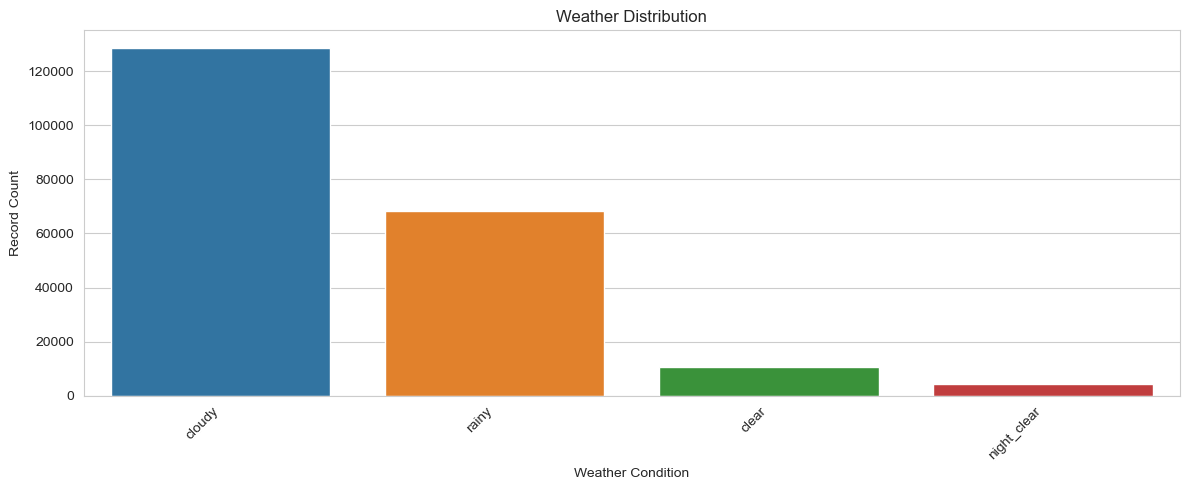

In [45]:
if weather_col:
    weather_counts = clean_df[weather_col].astype(str).value_counts().head(15).reset_index()
    weather_counts.columns = ["weather", "record_count"]
    display(weather_counts)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=weather_counts, x="weather", y="record_count")
    plt.title("Weather Distribution")
    plt.xlabel("Weather Condition")
    plt.ylabel("Record Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    if target_col and target_col in clean_df.columns:
        temp_df = clean_df[[weather_col, target_col]].copy()
        temp_df[target_col] = pd.to_numeric(temp_df[target_col], errors="coerce")
        temp_df = temp_df.dropna()

        if not temp_df.empty:
            plt.figure(figsize=(12, 5))
            sns.boxplot(data=temp_df, x=weather_col, y=target_col)
            plt.title(f"{target_col} by Weather Condition")
            plt.xlabel("Weather Condition")
            plt.ylabel(target_col)
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
else:
    print("No weather column detected.")

,is_weekend,record_count
0,False,138745
1,True,73062


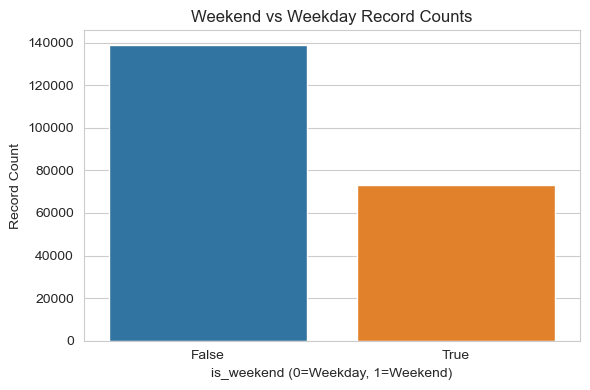

,is_holiday,record_count
0,False,196585
1,True,15222


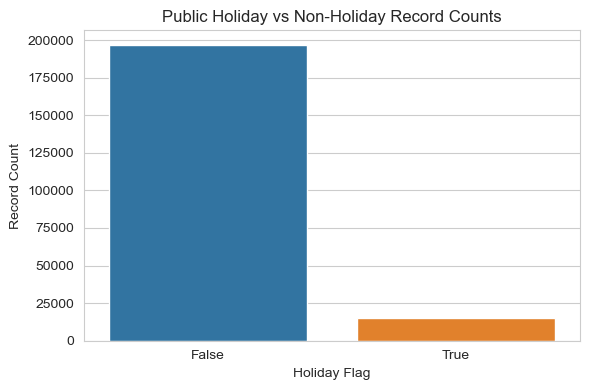

In [49]:
if "is_weekend" in clean_df.columns:
    weekend_counts = clean_df["is_weekend"].astype(str).value_counts().reset_index()
    weekend_counts.columns = ["is_weekend", "record_count"]
    display(weekend_counts)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=weekend_counts, x="is_weekend", y="record_count")
    plt.title("Weekend vs Weekday Record Counts")
    plt.xlabel("is_weekend (0=Weekday, 1=Weekend)")
    plt.ylabel("Record Count")
    plt.tight_layout()
    plt.show()

if holiday_col and holiday_col in clean_df.columns:
    holiday_counts = clean_df[holiday_col].astype(str).value_counts().reset_index()
    holiday_counts.columns = ["is_holiday", "record_count"]
    display(holiday_counts)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=holiday_counts, x="is_holiday", y="record_count")
    plt.title("Public Holiday vs Non-Holiday Record Counts")
    plt.xlabel("Holiday Flag")
    plt.ylabel("Record Count")
    plt.tight_layout()
    plt.show()

    if target_col:
        tmp = clean_df[[holiday_col, target_col]].copy()
        tmp[target_col] = pd.to_numeric(tmp[target_col], errors="coerce")
        tmp = tmp.dropna()

        if not tmp.empty:
            plt.figure(figsize=(6, 4))
            sns.boxplot(data=tmp, x=holiday_col, y=target_col)
            plt.title(f"{target_col} by Holiday Flag")
            plt.xlabel("Holiday Flag")
            plt.ylabel(target_col)
            plt.tight_layout()
            plt.show()
else:
    print("No public holiday column detected.")

hour_of_day,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
location_name,,,,,,,,,,,,,,,,
HLY EATING HOUSE,37,539,583,556,337,875,938,847,895,344,366,339,1024,1061,1038,1004
SEMBAWANG EATING HOUSE,21,507,501,511,339,890,855,859,921,343,342,372,1065,1039,1064,1107
6033 FOODCOURT LLP,39,564,496,527,350,873,905,882,888,324,348,325,1069,1113,993,1039
Chit Chat & Makan Eating House,23,494,508,494,344,829,871,877,856,340,341,367,1080,1096,1092,1053
THE FOOD COURT,34,530,533,495,395,851,925,863,867,336,341,328,995,1059,1070,1005


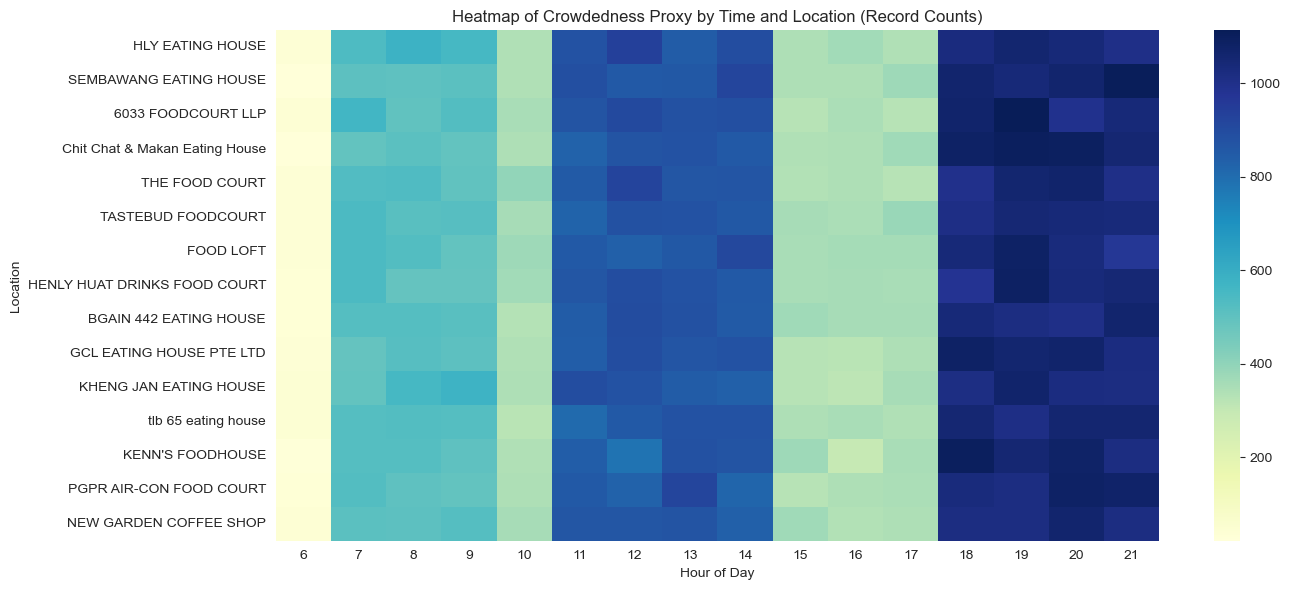

In [51]:
if location_col and "hour_of_day" in clean_df.columns:
    pivot_counts = pd.pivot_table(
        clean_df,
        index=location_col,
        columns="hour_of_day",
        values=target_col if target_col else clean_df.columns[0],
        aggfunc="count",
        fill_value=0
    )

    pivot_counts = pivot_counts.loc[pivot_counts.sum(axis=1).sort_values(ascending=False).head(15).index]

    display(pivot_counts.head())

    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot_counts, cmap="YlGnBu")
    plt.title("Heatmap of Crowdedness Proxy by Time and Location (Record Counts)")
    plt.xlabel("Hour of Day")
    plt.ylabel("Location")
    plt.tight_layout()
    plt.show()
else:
    print("Need both location and hour_of_day columns for time-location heatmap.")

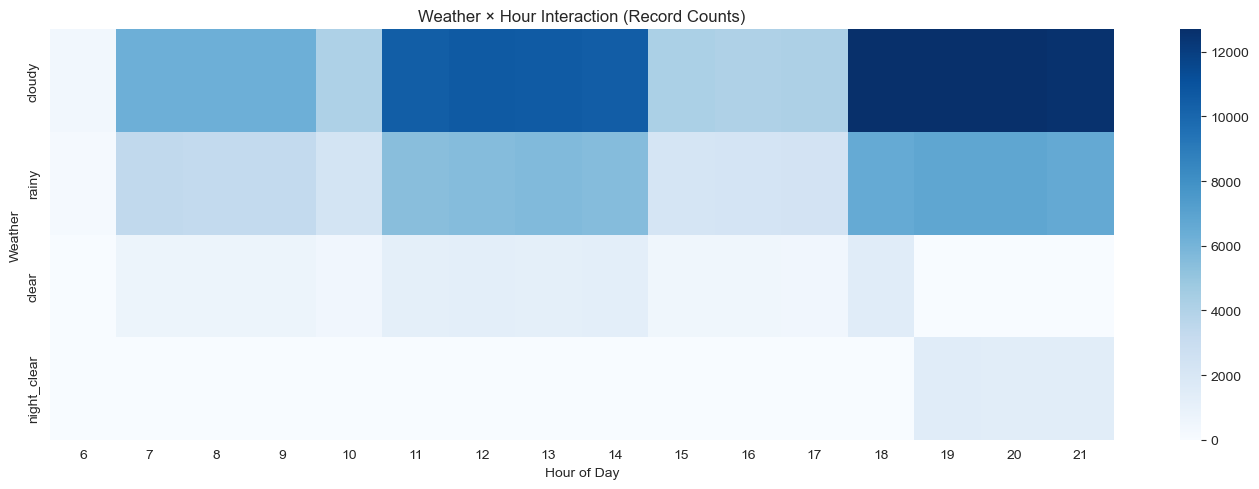

In [53]:
if weather_col and "hour_of_day" in clean_df.columns:
    weather_hour = pd.crosstab(clean_df[weather_col].astype(str), clean_df["hour_of_day"])
    weather_hour = weather_hour.loc[weather_hour.sum(axis=1).sort_values(ascending=False).head(10).index]

    plt.figure(figsize=(14, 5))
    sns.heatmap(weather_hour, cmap="Blues")
    plt.title("Weather × Hour Interaction (Record Counts)")
    plt.xlabel("Hour of Day")
    plt.ylabel("Weather")
    plt.tight_layout()
    plt.show()
else:
    print("Weather × Hour interaction skipped (missing columns).")

,record_id,day_of_week,hour_of_day,lat,long,temperature,humidity,location_id,month
record_id,1.00,-0.00,0.00,0.37,-0.85,0.02,-0.02,1.00,0.05
day_of_week,-0.00,1.00,-0.00,-0.00,0.00,0.04,-0.00,-0.00,0.03
hour_of_day,0.00,-0.00,1.00,0.00,0.00,-0.04,-0.00,0.00,-0.00
lat,0.37,-0.00,0.00,1.00,-0.75,0.00,-0.00,0.37,-0.00
long,-0.85,0.00,0.00,-0.75,1.00,-0.00,0.00,-0.85,-0.00
temperature,0.02,0.04,-0.04,0.00,-0.00,1.00,-0.75,0.00,0.43
humidity,-0.02,-0.00,-0.00,-0.00,0.00,-0.75,1.00,-0.00,-0.39
location_id,1.00,-0.00,0.00,0.37,-0.85,0.00,-0.00,1.00,0.00
month,0.05,0.03,-0.00,-0.00,-0.00,0.43,-0.39,0.00,1.00


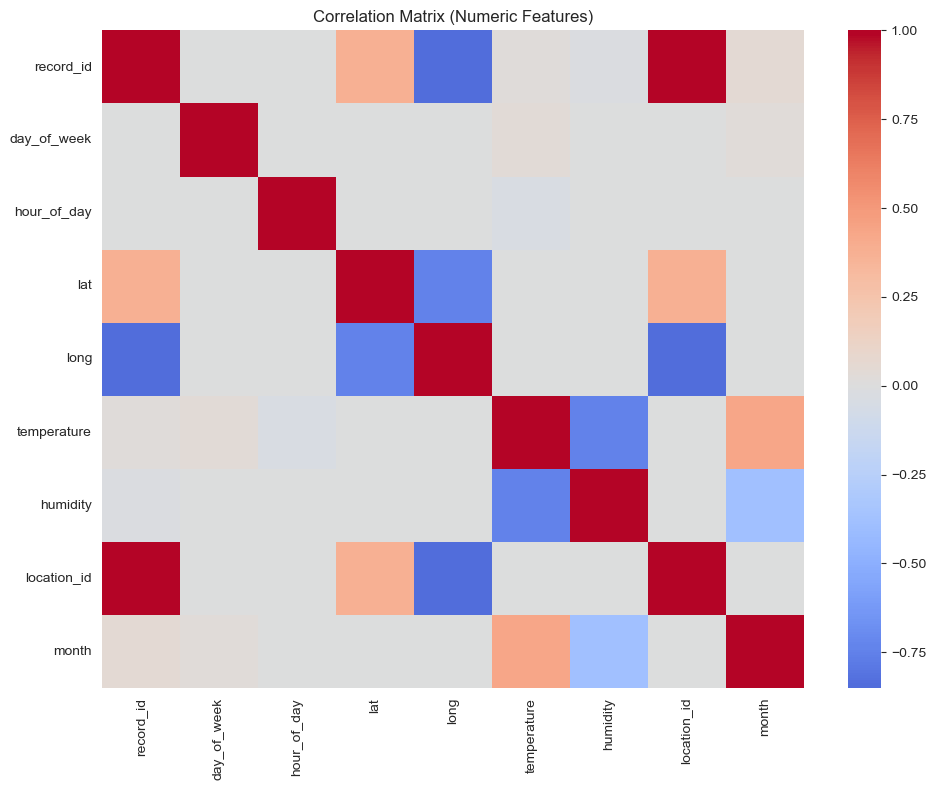

In [54]:
numeric_df = clean_df.select_dtypes(include=[np.number]).copy()

if not numeric_df.empty and numeric_df.shape[1] >= 2:
    corr = numeric_df.corr(numeric_only=True)
    display(corr.round(2))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
    plt.title("Correlation Matrix (Numeric Features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation matrix.")

,event_date,record_count,zscore,is_anomaly
122,2025-05-03,2047,4.476457,True
157,2025-06-07,2114,4.821079,True


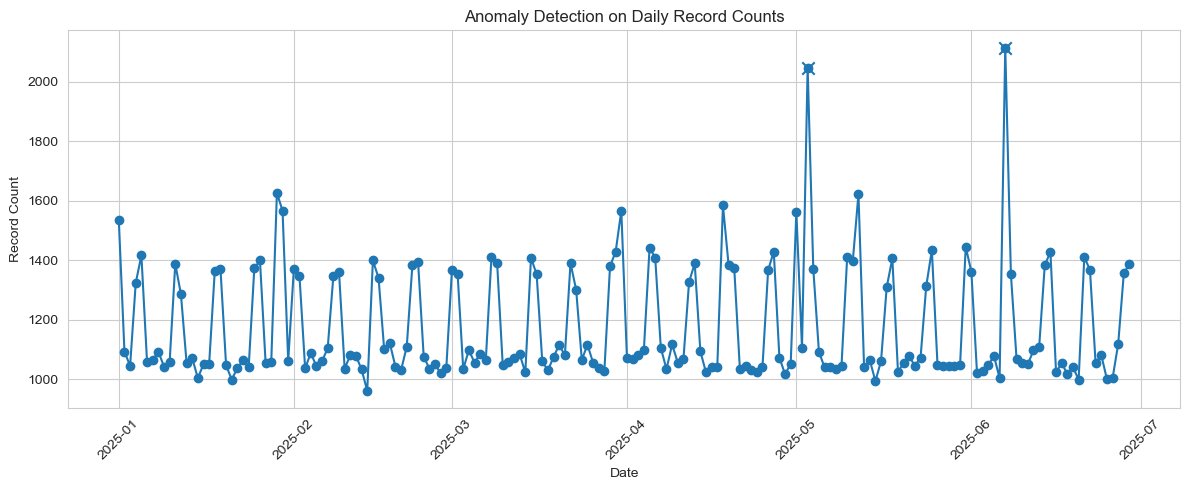

In [55]:
if target_col and target_col in clean_df.columns:
    anomaly_df = clean_df[[target_col]].copy()
    anomaly_df[target_col] = pd.to_numeric(anomaly_df[target_col], errors="coerce")
    anomaly_df = anomaly_df.dropna()

    if len(anomaly_df) > 0:
        mu = anomaly_df[target_col].mean()
        sigma = anomaly_df[target_col].std()

        if sigma and sigma > 0:
            anomaly_df["zscore"] = (anomaly_df[target_col] - mu) / sigma
            anomaly_df["is_anomaly"] = anomaly_df["zscore"].abs() > 3

            print("Anomalies found:", anomaly_df["is_anomaly"].sum())
            display(anomaly_df[anomaly_df["is_anomaly"]].head(20))

            plt.figure(figsize=(12, 5))
            plt.plot(anomaly_df[target_col].values, label=target_col)
            anomaly_idx = np.where(anomaly_df["is_anomaly"])[0]
            plt.scatter(anomaly_idx, anomaly_df.iloc[anomaly_idx][target_col].values, marker="x", s=60, label="Anomaly")
            plt.title(f"Anomaly Detection on {target_col} (Z-score > 3)")
            plt.xlabel("Row Index")
            plt.ylabel(target_col)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("Target std is zero; anomaly detection skipped.")
else:
    if "event_date" in clean_df.columns:
        daily_counts = clean_df.groupby("event_date").size().reset_index(name="record_count")
        daily_counts["event_date"] = pd.to_datetime(daily_counts["event_date"], errors="coerce")
        daily_counts = daily_counts.dropna().sort_values("event_date")

        if len(daily_counts) > 2:
            mu = daily_counts["record_count"].mean()
            sigma = daily_counts["record_count"].std()
            if sigma and sigma > 0:
                daily_counts["zscore"] = (daily_counts["record_count"] - mu) / sigma
                daily_counts["is_anomaly"] = daily_counts["zscore"].abs() > 3

                display(daily_counts[daily_counts["is_anomaly"]])

                plt.figure(figsize=(12, 5))
                plt.plot(daily_counts["event_date"], daily_counts["record_count"], marker="o")
                outliers = daily_counts[daily_counts["is_anomaly"]]
                plt.scatter(outliers["event_date"], outliers["record_count"], marker="x", s=80)
                plt.title("Anomaly Detection on Daily Record Counts")
                plt.xlabel("Date")
                plt.ylabel("Record Count")
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
    else:
        print("No target column and no event_date column for anomaly detection.")

event_date
2025-01-01    1534
2025-01-02    1093
2025-01-03    1045
2025-01-04    1324
2025-01-05    1416
2025-01-06    1059
2025-01-07    1064
2025-01-08    1093
2025-01-09    1043
2025-01-10    1057
2025-01-11    1388
2025-01-12    1286
2025-01-13    1056
2025-01-14    1071
2025-01-15    1004
dtype: int64

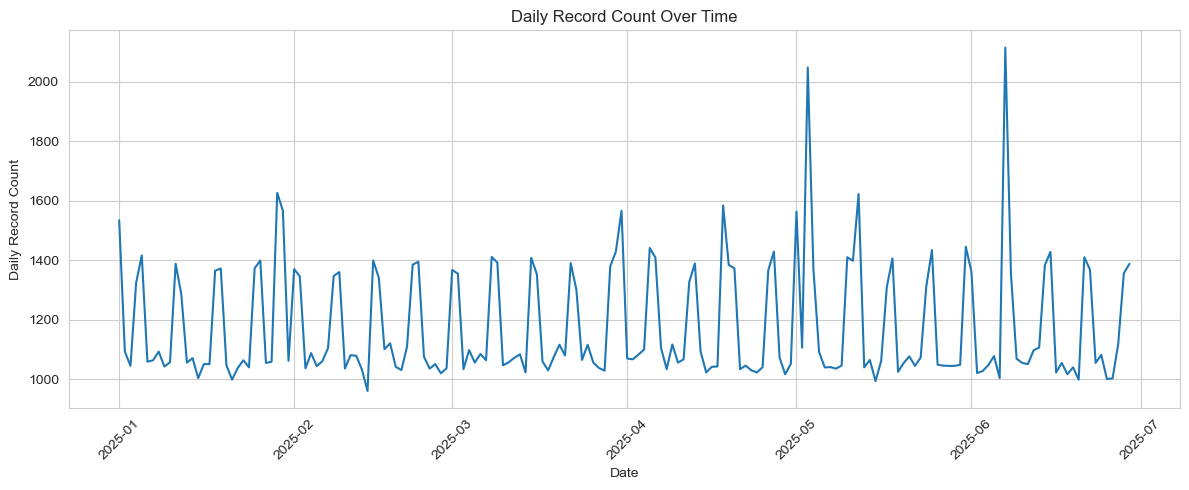

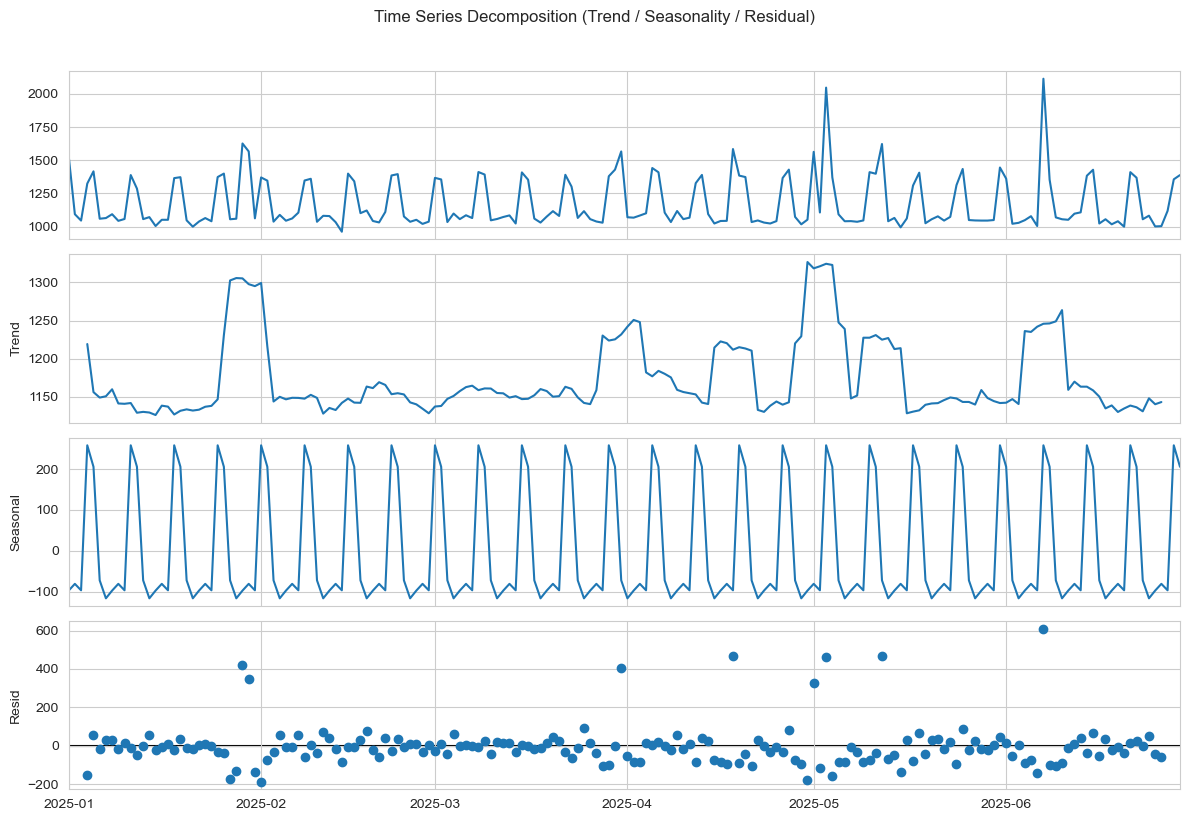

In [57]:
if "event_date" in clean_df.columns:
    if target_col and target_col in clean_df.columns:
        ts_df = clean_df[[ "event_date", target_col ]].copy()
        ts_df["event_date"] = pd.to_datetime(ts_df["event_date"], errors="coerce")
        ts_df[target_col] = pd.to_numeric(ts_df[target_col], errors="coerce")
        ts_df = ts_df.dropna()

        daily_ts = ts_df.groupby("event_date")[target_col].mean().sort_index()
        series_name = f"Daily Mean {target_col}"
    else:
        tmp = clean_df.copy()
        tmp["event_date"] = pd.to_datetime(tmp["event_date"], errors="coerce")
        tmp = tmp.dropna(subset=["event_date"])
        daily_ts = tmp.groupby("event_date").size().sort_index()
        series_name = "Daily Record Count"

    display(daily_ts.head(15))

    plt.figure(figsize=(12, 5))
    plt.plot(daily_ts.index, daily_ts.values)
    plt.title(f"{series_name} Over Time")
    plt.xlabel("Date")
    plt.ylabel(series_name)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    if len(daily_ts) >= 14:
        try:
            decomp = seasonal_decompose(daily_ts.asfreq("D").interpolate(), model="additive", period=7)
            fig = decomp.plot()
            fig.set_size_inches(12, 8)
            fig.suptitle("Time Series Decomposition (Trend / Seasonality / Residual)", y=1.02)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("Decomposition skipped:", e)
    else:
        print("Not enough daily data points for decomposition (need at least ~14).")
else:
    print("event_date column not available for seasonality/decomposition.")

In [66]:
# Feature Importance (Robust Version)

fallback_target = None  # e.g. "crowd_count" or "crowdedness"

if "target_col" not in globals() or target_col is None:
    try:
        target_col = infer_target_column(clean_df)
    except:
        target_col = None

if target_col is None and fallback_target is not None and fallback_target in clean_df.columns:
    target_col = fallback_target

print("Detected target_col:", target_col)

# 2) If still not found, show columns so you can choose manually
if target_col is None or target_col not in clean_df.columns:
    print("Target column not detected; feature importance skipped.")
    print("\nAvailable columns in clean_df:")
    print(clean_df.columns.tolist())

else:
    model_df = clean_df.copy()

    # Convert target to numeric (required for RandomForestRegressor)
    model_df[target_col] = pd.to_numeric(model_df[target_col], errors="coerce")
    model_df = model_df.dropna(subset=[target_col])

    if model_df.empty:
        print(f"All rows in target column '{target_col}' became NaN after numeric conversion.")
        print("If your target is categorical (e.g., low/medium/high), map it to numbers first.")
    else:
        # 3) Build candidate feature list
        exclude_cols = {
            target_col,
            "_dt",
            "event_date"
        }

        # Optional: exclude obvious leakage columns if they exist (edit if needed)
        possible_leakage_cols = {
            "prediction", "predicted_value", "predicted_count",
            "target", "label", "y"  # keep/remove depending on your dataset
        }

        # Remove leakage names only if they are NOT the chosen target
        for c in list(possible_leakage_cols):
            if c != target_col and c in model_df.columns:
                exclude_cols.add(c)

        candidate_features = [c for c in model_df.columns if c not in exclude_cols]

        if not candidate_features:
            print("No candidate features available.")
        else:
            X = model_df[candidate_features].copy()
            y = model_df[target_col].copy()

            # 4) Convert datetime-like columns safely
            for col in X.columns:
                try:
                    if pd.api.types.is_datetime64_any_dtype(X[col]):
                        X[col] = X[col].astype("int64") // 10**9
                    elif X[col].dtype == "object":
                        # Try parse as datetime only if many values look date-like
                        parsed = pd.to_datetime(X[col], errors="coerce")
                        if parsed.notna().mean() > 0.8:  # mostly datetime-like
                            X[col] = parsed.astype("int64") // 10**9
                except Exception:
                    pass

            # 5) Encode categoricals
            X = pd.get_dummies(X, drop_first=True)

            # 6) Clean numeric issues
            X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

            # Drop constant columns (optional but helpful)
            nunique = X.nunique(dropna=False)
            X = X.loc[:, nunique > 1]

            print("Rows available for modeling:", len(X))
            print("Feature columns after encoding:", X.shape[1])

            if X.shape[1] == 0:
                print("No usable features after preprocessing/encoding.")
            elif len(X) <= 20:
                print("Not enough usable rows for feature importance model (need > 20 rows).")
            else:
                # 7) Train/test split
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.2, random_state=42
                )

                # 8) Train baseline RF model
                rf = RandomForestRegressor(
                    n_estimators=100,
                    random_state=42,
                    n_jobs=-1
                )
                rf.fit(X_train, y_train)

                # 9) Evaluate baseline
                pred = rf.predict(X_test)
                mae = mean_absolute_error(y_test, pred)
                print(f"RandomForest baseline MAE: {mae:.4f}")

                # 10) Feature importance table + chart
                feat_imp = pd.DataFrame({
                    "feature": X.columns,
                    "importance": rf.feature_importances_
                }).sort_values("importance", ascending=False)

                top_n = min(20, len(feat_imp))
                feat_imp_top = feat_imp.head(top_n)

                display(feat_imp_top)

                plt.figure(figsize=(12, 6))
                sns.barplot(data=feat_imp_top, x="importance", y="feature")
                plt.title(f"Top {top_n} Feature Importances (Random Forest)")
                plt.xlabel("Importance")
                plt.ylabel("Feature")
                plt.tight_layout()
                plt.show()

Detected target_col: None
Target column not detected; feature importance skipped.

Available columns in clean_df:
['record_id', 'timestamp', 'day_of_week', 'hour_of_day', 'is_weekend', 'is_public_holiday', 'lat', 'long', 'weather', 'temperature', 'humidity', 'location_id', 'location_name', '_dt', 'event_date', 'month']


## EDA Summary (Key Findings)

- Data cleaning reduced duplicates and inconsistencies in categorical labels.
- Missing values improved in key columns after cleaning.
- Temporal patterns show peak activity at specific hours and weekday/weekend differences.
- Location distribution is uneven, with a few locations contributing most records.
- Weather and holiday flags show measurable differences in crowdedness/record distribution.
- Cross-feature heatmaps reveal interaction effects across time, location, and weather.
- Anomaly detection identified unusual spikes/drops for further inspection.
- Seasonal trend and decomposition provide useful signals for feature engineering.
- Feature importance highlights the strongest predictors for model training.